In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [3]:
data = pd.read_csv("data/raw_data/project_data.csv")

print("Shape of dataset:", data.shape)
data.head()

Shape of dataset: (7999, 21)


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,0.000,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,0.650,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,0.003,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,0.710,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,NaN,0.13,0.001,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
print("\n--- Dataset Info ---")
print(data.info())

print("\n--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Duplicate Rows ---")
print(data.duplicated().sum())

print("\n--- Statistical Summary ---")
print(data.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7751 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7935 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   object 
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7732 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null

In [5]:
# Fill numerical NaNs with mean
num_cols = data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    data[col].fillna(data[col].mean(), inplace=True)

# Drop duplicates
data.drop_duplicates(inplace=True)

# Ensure correct dtypes
data[num_cols] = data[num_cols].astype(float)

print("\nAfter cleaning:")
print(data.info())


After cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   object 
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   fl

C:\Users\moham\AppData\Local\Temp\ipykernel_31288\1873883072.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [6]:
# Feature Engineering

thresholds = {
    "aluminium": 2.8,
    "ammonia": 32.5,
    "arsenic": 0.01,
    "barium": 2,
    "cadmium": 0.005,
    "chloramine": 4,
    "chromium": 0.1,
    "copper": 1.3,
    "fluoride": 1.5,
    "bacteria": 0,
    "viruses": 0,
    "lead": 0.015,
    "nitrates": 10,
    "nitrites": 1,
    "mercury": 0.002,
    "perchlorate": 56,
    "radium": 5,
    "selenium": 0.5,
    "silver": 0.1,
    "uranium": 0.3,
}

for col, th in thresholds.items():
    if col in data.columns:
        # Convert column to numeric if not already
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[f"{col}_high"] = (data[col] > th).astype(int)

print("\nFeature engineering done. Sample columns:")
print(data.iloc[0, :15])  # print some cols for check



Feature engineering done. Sample columns:
aluminium      1.65
ammonia        9.08
arsenic        0.04
barium         2.85
cadmium       0.007
chloramine     0.35
chromium       0.83
copper         0.17
flouride       0.05
bacteria        0.2
viruses         0.0
lead          0.054
nitrates      16.08
nitrites       1.13
mercury       0.007
Name: 0, dtype: object


In [7]:
# Convert is_safe to numeric and handle invalid entries
data["is_safe"] = pd.to_numeric(data["is_safe"], errors="coerce")

# Drop rows where is_safe is NaN after conversion
data = data.dropna(subset=["is_safe"])

# Ensure it's int (0 or 1)
data["is_safe"] = data["is_safe"].astype(int)


C:\Users\moham\AppData\Local\Temp\ipykernel_31288\3714280087.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="is_safe", data=data, palette="coolwarm")


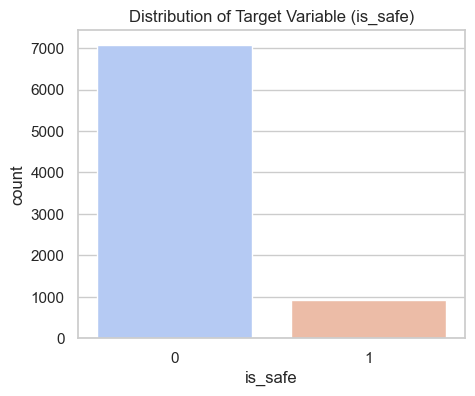

In [8]:
# EDA
# ---- Distribution of Target ----
plt.figure(figsize=(5,4))
sns.countplot(x="is_safe", data=data, palette="coolwarm")
plt.title("Distribution of Target Variable (is_safe)")
plt.show()


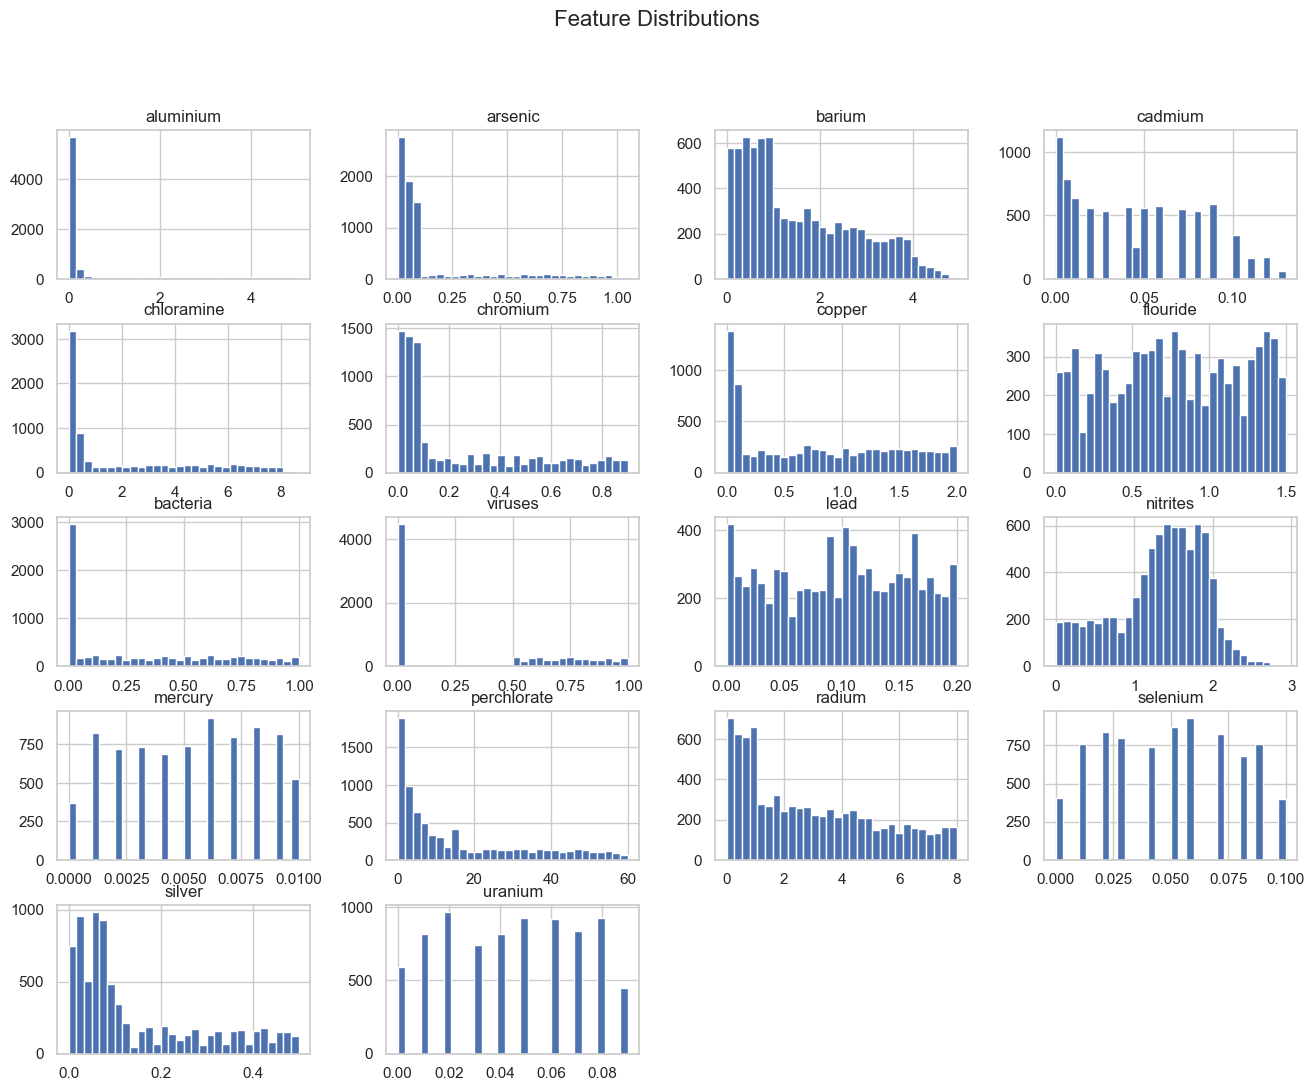

In [9]:
# ---- Distribution of Features ----
num_features = [col for col in num_cols if col != "is_safe"]

data[num_features].hist(figsize=(16,12), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

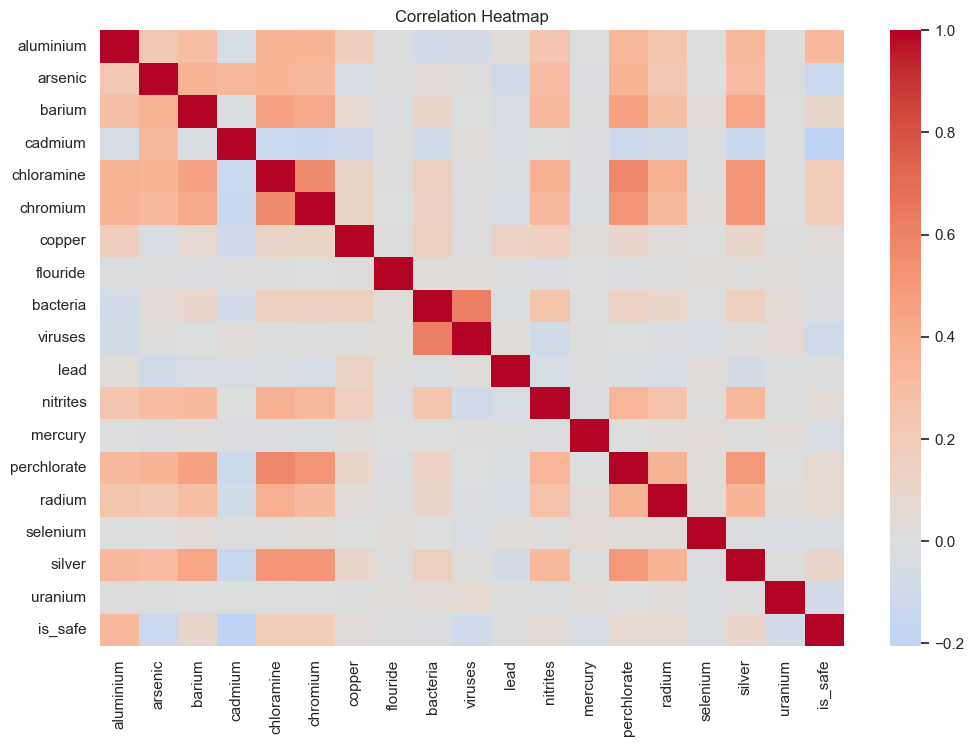

In [10]:
# ---- Correlation Heatmap ----

data_clean = data.replace('#NUM!', np.nan)

plt.figure(figsize=(12,8))
corr = data_clean[num_features + ["is_safe"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_31288\1342736433.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, x="is_safe", palette="Set2")
C:\Users\moham\AppData\Local\Temp\ipykernel_31288\1342736433.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, x="is_safe", palette="Set2")
C:\Users\moham\AppData\Local\Temp\ipykernel_31288\1342736433.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, x="is_safe", palette="Set2")
C:\Users\moham\AppData\Local\Temp\ipykernel_31288\1342736433.py:5: 

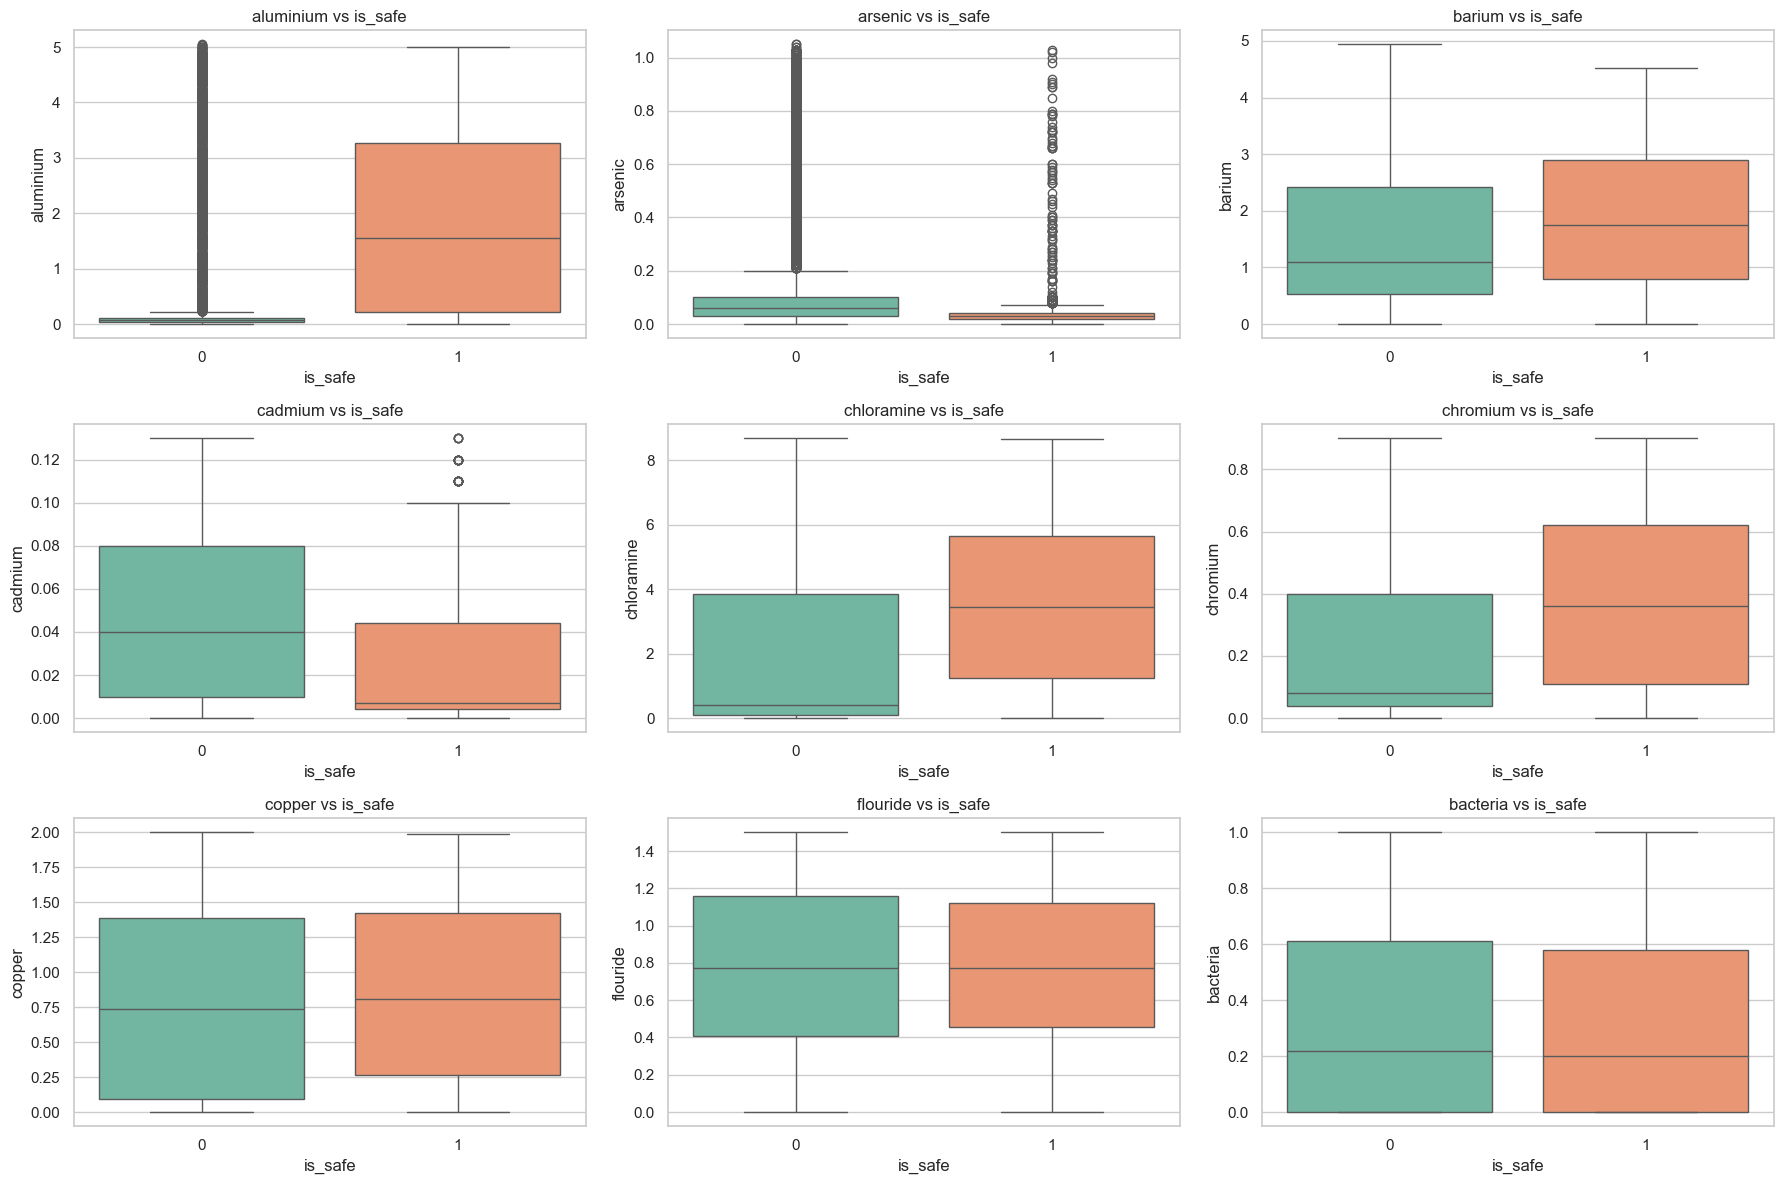

In [11]:
# ---- Boxplots to check outliers ----
plt.figure(figsize=(18,12))
for i, col in enumerate(num_features[:9], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=data, y=col, x="is_safe", palette="Set2")
    plt.title(f"{col} vs is_safe")
plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_31288\3447944122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="is_safe", y="nitrates", palette="muted")


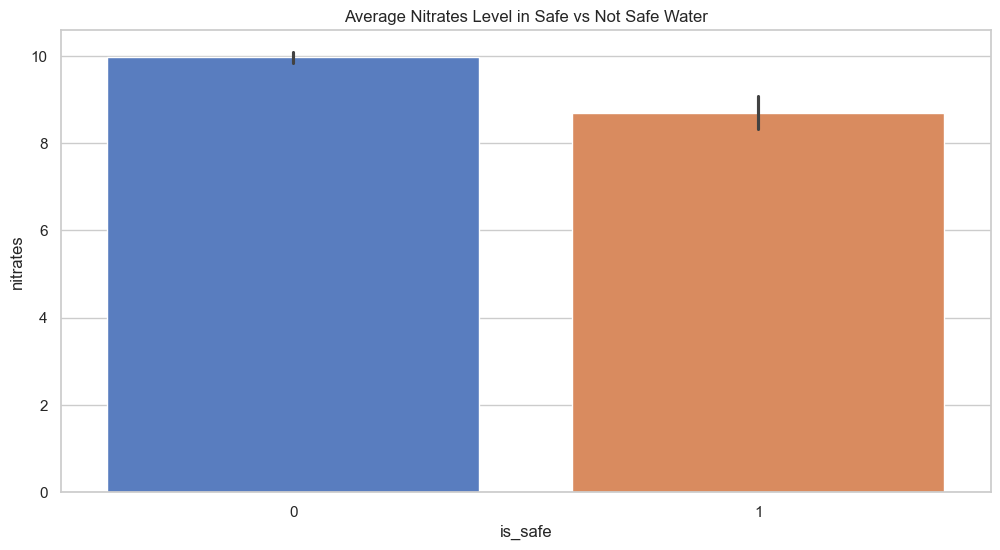

In [12]:
# ---- Compare Safe vs Not Safe ----
plt.figure(figsize=(12,6))
sns.barplot(data=data, x="is_safe", y="nitrates", palette="muted")
plt.title("Average Nitrates Level in Safe vs Not Safe Water")
plt.show()


In [13]:
scaler = StandardScaler()
scaled = scaler.fit_transform(data[num_features])
scaled_df = pd.DataFrame(scaled, columns=num_features)

print("\nPreview of scaled data:")
print(scaled_df.head())


Preview of scaled data:
   aluminium   arsenic    barium   cadmium  chloramine  chromium    copper  \
0   0.777403 -0.480875  1.054205 -1.046253   -0.711941  2.152993 -0.973050   
1   1.306945 -0.599632  1.432447 -1.187536    1.208552  1.598765 -0.223303   
2   0.271572 -0.480875 -0.812340 -1.017996    0.803417  1.044536 -1.202564   
3   0.548198 -0.480875  1.144654 -1.215793    1.968179 -0.802892  1.306793   
4   0.200439 -0.520460 -1.124801 -1.074510    0.191820  1.635713 -0.361012   

   flouride  bacteria   viruses      lead  nitrites   mercury  perchlorate  \
0 -1.665241 -0.363345 -0.869387 -0.781070 -0.348629  0.609178     1.263417   
1  0.295157  1.002460  0.849782  0.009785  1.046960 -0.739005     0.944840   
2  0.502729 -0.818614 -0.861452 -0.368450 -0.383518  0.272132     1.990513   
3  0.710301  1.184567  1.008475 -1.434385 -0.069511 -0.401960    -0.397939   
4 -0.000186 -0.575804 -0.866742  0.302058 -0.383518 -0.739005     0.053523   

     radium  selenium    silver   ura

In [14]:
from sklearn.model_selection import train_test_split

# Features (exclude target)
X = data.drop(columns=["is_safe"])
y = data["is_safe"]

# Train-test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5597, 39)
Test shape: (2399, 39)


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Updated model definitions with pipelines
models = {
    "LogisticRegression": (Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500))
    ]), {
        "clf__C": [0.1, 1, 10],
        "clf__solver": ["liblinear", "lbfgs"]
    }),

    "KNN": (Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]), {
        "clf__n_neighbors": [3, 5, 7, 9],
        "clf__weights": ["uniform", "distance"]
    }),

    "RandomForest": (Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("clf", RandomForestClassifier(random_state=42))
    ]), {
        "clf__n_estimators": [50, 100, 200],
        "clf__max_depth": [None, 5, 10]
    }),

    "SVM": (Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True))
    ]), {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["linear", "rbf"]
    }),
}


best_models = {}
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"\n{name} best params: {grid.best_params_}")
    print(f"{name} best CV score: {grid.best_score_:.4f}")



LogisticRegression best params: {'clf__C': 10, 'clf__solver': 'lbfgs'}
LogisticRegression best CV score: 0.9083

KNN best params: {'clf__n_neighbors': 7, 'clf__weights': 'uniform'}
KNN best CV score: 0.9017

RandomForest best params: {'clf__max_depth': None, 'clf__n_estimators': 200}
RandomForest best CV score: 0.9444

SVM best params: {'clf__C': 10, 'clf__kernel': 'rbf'}
SVM best CV score: 0.9335



=== LogisticRegression Evaluation ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      2125
           1       0.68      0.39      0.50       274

    accuracy                           0.91      2399
   macro avg       0.80      0.68      0.72      2399
weighted avg       0.90      0.91      0.90      2399

Confusion Matrix:
 [[2074   51]
 [ 167  107]]


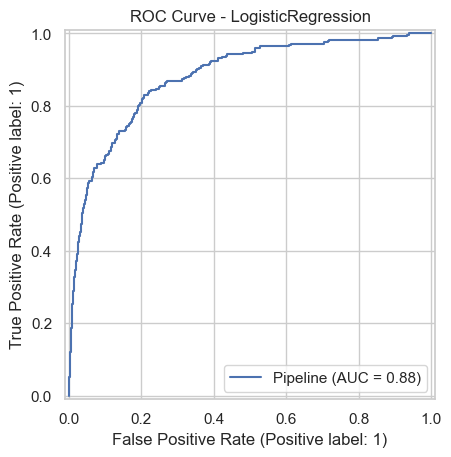

c:\Users\moham\Infosys Project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\moham\Infosys Project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\moham\Infosys Project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in 


=== KNN Evaluation ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      2125
           1       0.67      0.30      0.41       274

    accuracy                           0.90      2399
   macro avg       0.79      0.64      0.68      2399
weighted avg       0.89      0.90      0.89      2399

Confusion Matrix:
 [[2085   40]
 [ 192   82]]


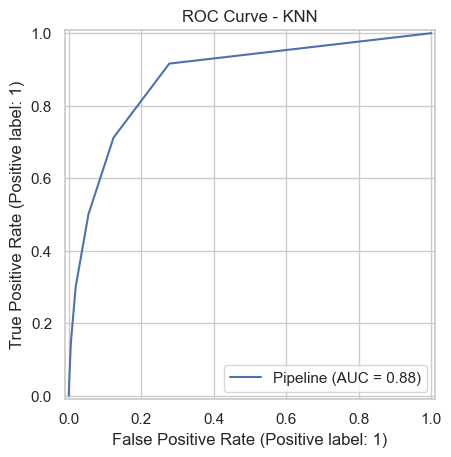


=== RandomForest Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2125
           1       0.88      0.68      0.76       274

    accuracy                           0.95      2399
   macro avg       0.92      0.83      0.87      2399
weighted avg       0.95      0.95      0.95      2399

Confusion Matrix:
 [[2099   26]
 [  89  185]]


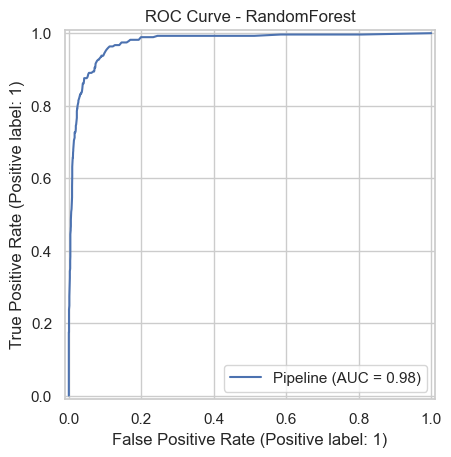


=== SVM Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2125
           1       0.70      0.67      0.69       274

    accuracy                           0.93      2399
   macro avg       0.83      0.82      0.82      2399
weighted avg       0.93      0.93      0.93      2399

Confusion Matrix:
 [[2048   77]
 [  91  183]]


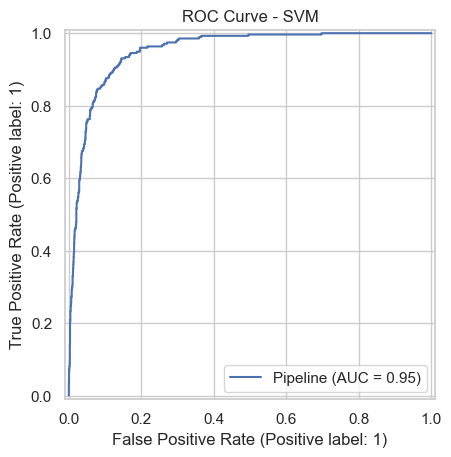

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    results.append([name, acc, prec, rec, f1, auc])
    
    print(f"\n=== {name} Evaluation ===")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    if y_proba is not None:
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(f"ROC Curve - {name}")
        plt.show()


In [19]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print("\nModel Comparison:")
print(results_df.sort_values(by="Accuracy", ascending=False))


Model Comparison:
                Model  Accuracy  Precision    Recall        F1   ROC-AUC
2        RandomForest  0.952063   0.876777  0.675182  0.762887  0.975291
3                 SVM  0.929971   0.703846  0.667883  0.685393  0.952362
0  LogisticRegression  0.909129   0.677215  0.390511  0.495370  0.880438
1                 KNN  0.903293   0.672131  0.299270  0.414141  0.877122
